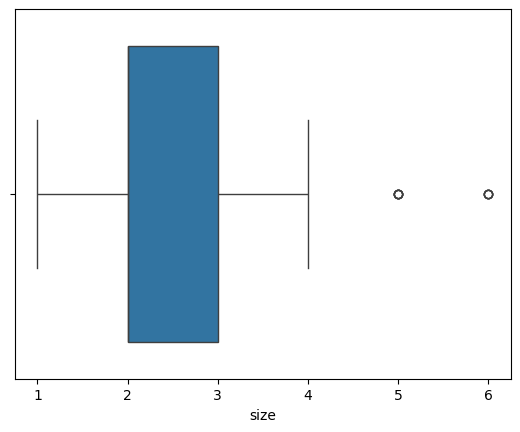

IQR Outliers 88
Zscore Outliers 4


In [6]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from scipy.stats import zscore
df=sns.load_dataset('tips')
#Box plot
sns.boxplot(x=df['size'])
plt.show()
#IQR method
Q1=df['size'].quantile(0.25)
Q3=df['size'].quantile(0.25)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
#outliers
outliers=df[(df['size']<lower_bound)|(df['size']>upper_bound)]
print('IQR Outliers',len(outliers))
#Zscore Method 
df['size_zscore']=zscore(df['size'])
outliers_z=df[abs(df['size_zscore'])>3]
print('Zscore Outliers',len(outliers_z))

# EDA:Exploratory Data Analysis
### understand the sturucture of dataset,identife missing values,detect outliers,understand feature distrubition,find relationship between variables,check data quality issue,prepare data for ML
## Types:
## univarient Analysis - Analyzing one variable at a time - mean,boxplot,histogram
## Bivarient - two variable
## Multivarient - More than Two

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')
count    244.000000
mean      19.785943
s

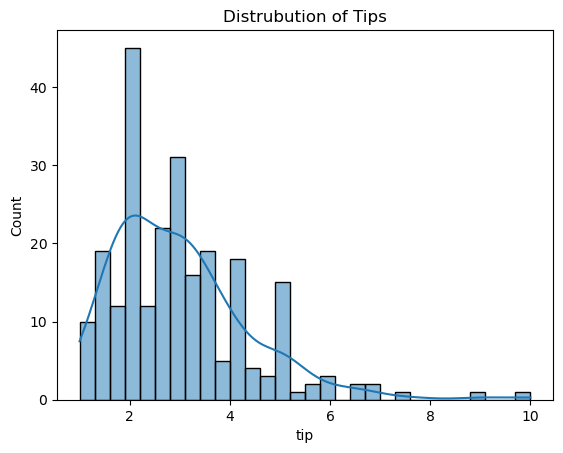

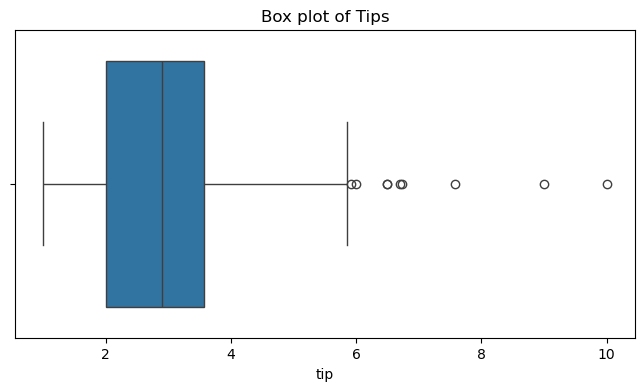

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


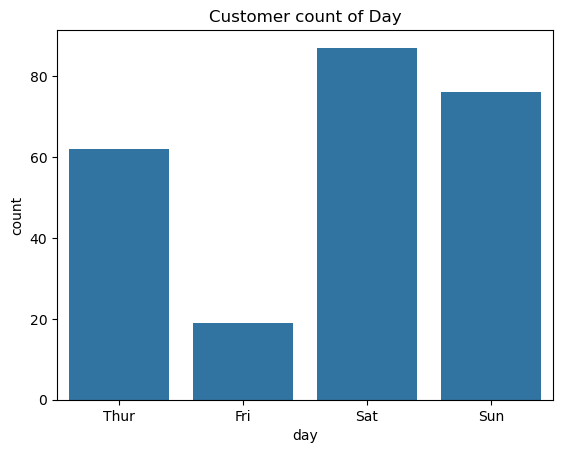

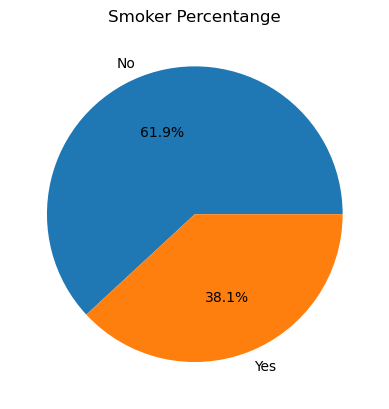

IQR Outliers 211


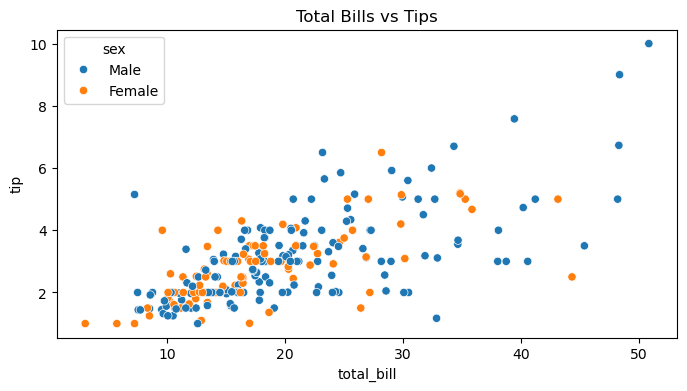

Correlation: 0.6757341092113641


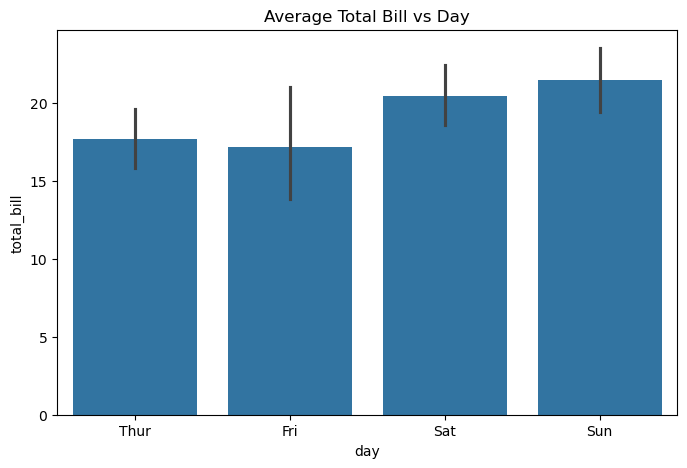

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64
day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64


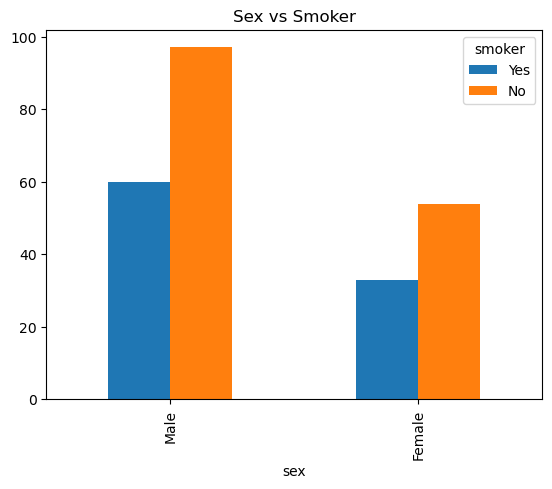

In [23]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
df=sns.load_dataset('tips')
print(df.head())
print(df.info())
print(df.columns)

#1.Descriptive Stastical
print(df['total_bill'].describe())

#2.Histogram
sns.histplot(df['tip'],bins=30,kde=True)
plt.title('Distrubution of Tips')
plt.show()

#Outlier
plt.figure(figsize=(8,4))
sns.boxplot(x=df['tip'])
plt.title('Box plot of Tips')
plt.show()

# Categorical variable
print(df['day'].value_counts())

# count plot
sns.countplot(x='day',data=df)
plt.title('Customer count of Day')
plt.show()

#Pie Chart
df['smoker'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Smoker Percentange')
plt.ylabel("")
plt.show()

#Outlier Detection Using IQR
Q1=df['tip'].quantile(0.25)
Q3=df['tip'].quantile(0.25)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
#outliers
outliers=df[(df['tip']<lower_bound)|(df['tip']>upper_bound)]
print('IQR Outliers',len(outliers))

#Bivaerient
plt.figure(figsize=(8,4))
sns.scatterplot(
    x='total_bill',
    y='tip',
    hue='sex',
    data=df
)
plt.title('Total Bills vs Tips')
plt.show()

#Correlation 
#Pearson correlation
corr=df['total_bill'].corr(df['tip'])
print('Correlation:',corr)

#Bar chart
plt.figure(figsize=(8,5))
sns.barplot(
    x='day',
    y='total_bill',
    data=df
)
plt.title('Average Total Bill vs Day')
plt.show()

#Group Statistics
#Mean Bill by Day
print(df.groupby('day',observed=False)['total_bill'].mean()) #observed=False - to avoid warning in runtime 
#Multiple Statistics
print(df.groupby('day',observed=False)['total_bill'].agg('mean','median','min','max'))

#Bar Chart
pd.crosstab(
    df['sex'],
    df['smoker']
).plot(kind='bar')
plt.title('Sex vs Smoker')
plt.show()



# Bivarient 


In [ ]:
#Bivaerient
plt.figure(figsize=(8,4))
sns.scatterplot(
    x='total_bill',
    y='tip',
    hue='sex',
    data=df
)
plt.title('Total Bills vs Tips')
plt.show()

#Correlation 
#Pearson correlation
corr=df['total_bill'].corr(df['tip'])
print('Correlation:',corr)

#Bar chart
plt.figure(figsize=(8,5))
sns.barplot(
    x='day',
    y='total_bill',
    data=df
)
plt.title('Average Total Bill vs Day')
plt.show()

#Group Statistics
#Mean Bill by Day
print(df.groupby('day',observed=False)['total_bill'].mean()) #observed=False - to avoid warning in runtime 
#Multiple Statistics
print(df.groupby('day',observed=False)['total_bill'].agg('mean','median','min','max'))

#Bar Chart
pd.crosstab(
    df['sex'],
    df['smoker']
).plot(kind='bar')
plt.title('Sex vs Smoker')
plt.show()

# Multivarient:

### 1.discover hidden relationship,2.understand interaction among multiple features,3.detect dusters and patterns,4.Support features selection,5.prepare data for ML

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


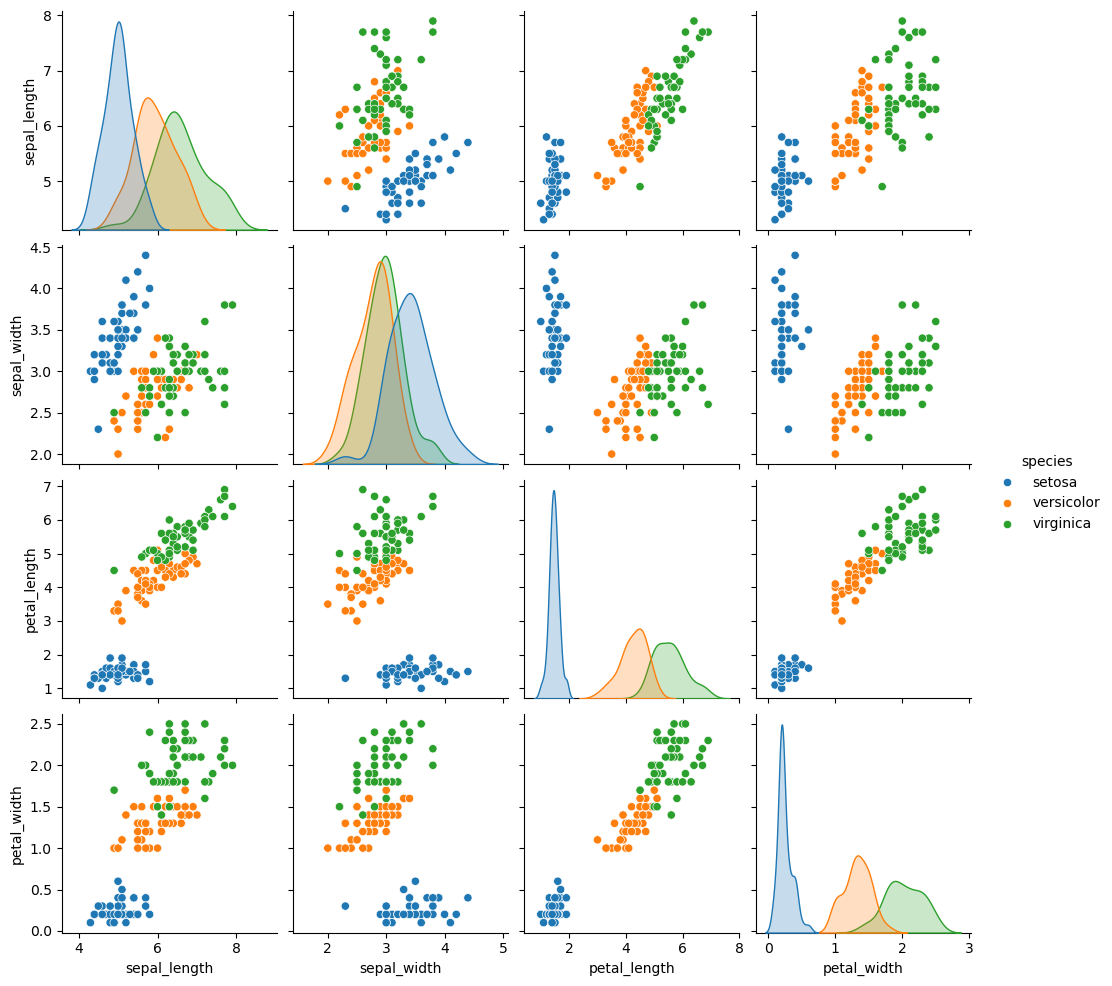

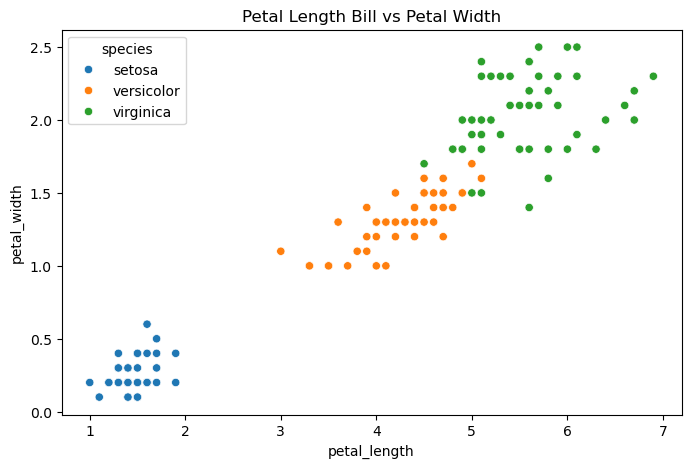

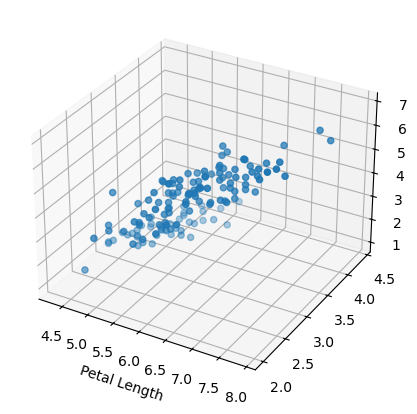

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


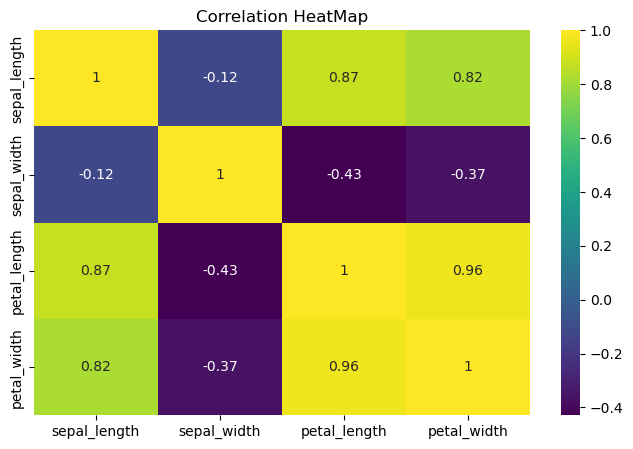

        Feature         VIF
0  sepal_length  262.969348
1   sepal_width   96.353292
2  petal_length  172.960962
3   petal_width   55.502060


In [55]:
#Pairplot
import seaborn as sns
import matplotlib.pyplot as plt
df =sns.load_dataset('iris')
print(df.columns)
sns.pairplot(
    df,
    hue='species'
)
plt.show()

#color-Coded Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='petal_length',
    y='petal_width',
    hue='species',
    data=df
)
plt.title('Petal Length Bill vs Petal Width')
plt.show()

#3D Scatter plot
from mpl_toolkits.mplot3d import Axes3D #Axes3D -  by create chart area
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(
    df['sepal_length'],
    df['sepal_width'],
    df['petal_length'])
ax.set_xlabel('Sepal Length')
ax.set_xlabel('Sepal Width')
ax.set_xlabel('Petal Length')
plt.show()

#Correlation Matrix
#multi
corr_matrix=df.corr(numeric_only=True)
print(corr_matrix)

#Correlation Matrix
plt.figure(figsize=(8,5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='viridis'
)
plt.title('Correlation HeatMap')
plt.show()

In [56]:
#VIF
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df.drop('species',axis=1)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values,i)
              for i in range(X.shape[1])]
print(vif)

        Feature         VIF
0  sepal_length  262.969348
1   sepal_width   96.353292
2  petal_length  172.960962
3   petal_width   55.502060


        Feature        VIF
0   sepal_width   5.856965
1  petal_length  62.071308
2   petal_width  43.292574


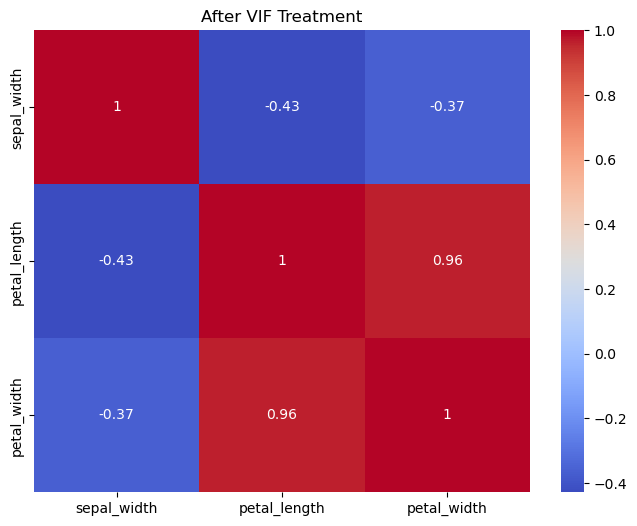

In [59]:
#After VIF
X_new = X.drop('sepal_length',axis=1)
vif_after=pd.DataFrame()
vif_after['Feature']=X_new.columns
vif_after['VIF']=[
    variance_inflation_factor(X_new.values,i)
    for i in range(X_new.shape[1])
]
print(vif_after)

#Heatmap After removing Features
plt.figure(figsize=(8,6))
sns.heatmap(
    X_new.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('After VIF Treatment')
plt.show()